In [54]:
import heapq
import sys

import matplotlib
import matplotlib.pyplot as plt

IS_FILE_INPUT = True
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False


def prim(G: dict[int, list[tuple[int, int]]]) -> list[tuple[int, int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(G.keys())
    ans: list[tuple[int, int]] = []
    used = {v: False for v in v_list}

    pre = v_list[0]
    used[pre] = True
    que = [(cost, v) for v, cost in G[pre]]
    heapq.heapify(que)
    while que:
        cost_v, v = heapq.heappop(que)
        if used[v]:
            continue
        used[v] = True
        ans.append((min(pre, v), max(pre, v)))
        pre = v
        for nxt, cost_nxt in G[v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, nxt))
    return ans


class Env:
    def __init__(self, input_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(list(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [[(l + r) / 2, (c + d) / 2] for l, r, c, d in rectangles]
        self._query_history: list[str] = []

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = abs(x1 - x2) ** 2 + abs(y1 - y2) ** 2
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
        output_file_path: str,
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"

        with open(output_file_path, "w") as f:
            for query_str in self._query_history:
                f.write(query_str + "\n")
            f.write(ans_str)

    def _input(self):
        W, D, N = map(int, input().split())
        a = []
        for d in range(D):
            a.append(list(map(int, input().split())))
        return W, D, N, a


def solve(env: Env):
    N, M, Q, L, W = env.N, env.M, env.Q, env.L, env.W
    G = env.G
    rectangles = env.rectangles
    lx, rx, ly, ry = [], [], [], []
    for n in range(N):
        a, b, c, d = rectangles[n]
        lx.append(a)
        rx.append(b)
        ly.append(c)
        ry.append(d)

    # use center of rectangle
    x = [(l + r) // 2 for l, r in zip(lx, rx)]
    y = [(l + r) // 2 for l, r in zip(ly, ry)]

    # split cities into groups
    cities = list(range(N))
    cities.sort(key=lambda i: (x[i], y[i]))
    groups = []
    start_idx = 0
    for g in G:
        groups.append(cities[start_idx : start_idx + g])
        start_idx += g

    # get edges from queries
    edges = []
    for k in range(M):
        edges.append([])
        for i in range(0, G[k] - 1, 2):
            if i < G[k] - 2:
                ret = env.query(groups[k][i : i + 3])
                edges[k].extend(ret)
            else:
                edges[k].append(groups[k][i : i + 2])

    env.answer(groups, edges, "../out/0000.txt")


env = Env("../in/0000.txt")


In [ ]:
from typing import List, Tuple
import numpy as np
from scipy.spatial import KDTree


def calc_dist(p1: tuple, p2: tuple) -> float:
    x_dff = p1[0] - p2[0]
    y_dff = p1[1] - p2[1]
    dist = (x_dff**2 + y_dff**2) ** 0.5
    return dist


def fast_greedy_pairing(points: List[Tuple[float, float]]) -> List[Tuple[int, int]]:
    points = np.array(points)
    n = len(points)
    used = np.zeros(n, dtype=bool)
    tree = KDTree(points)
    pairs = []

    for i in range(n):
        if used[i]:
            continue
        dists, indices = tree.query(points[i], k=min(30, n))
        for j in indices[1:]:
            if not used[j]:
                pairs.append((i, int(j)))
                used[i] = used[j] = True
                break

    return pairs


def farthest_point_sampling(points: np.ndarray, M: int) -> np.ndarray:
    N = len(points)
    selected_indices = []

    idx = np.random.randint(0, N)
    selected_indices.append(idx)
    min_distances = np.full(N, np.inf)

    for _ in range(1, M):
        last_point = points[selected_indices[-1]]
        distances = np.linalg.norm(points - last_point, axis=1)
        min_distances = np.minimum(min_distances, distances)
        next_idx = np.argmax(min_distances)
        selected_indices.append(int(next_idx))

    return selected_indices


def select_pairs(cneter_points, rectangles):
    N_POINT = 100
    N_PAIR = 20

    diffs = []
    for v, (l, r, t, b) in enumerate(rectangles):
        diffs.append((v, abs(l - r) + abs(t - b)))

    sorted_diffs = sorted(diffs, key=lambda x: x[1])

    target_diffs = sorted_diffs[:N_POINT]
    target_inds = [diff[0] for diff in target_diffs]
    target_points = [cneter_points[diff[0]] for diff in target_diffs]
    pairs = fast_greedy_pairing(target_points)
    pairs = [(target_inds[i], target_inds[j]) for i, j in pairs]
    pair_centers = []
    for v, q in pairs:
        pair_centers.append(
            [
                (cneter_points[v][0] + cneter_points[q][0]) / 2,
                (cneter_points[v][1] + cneter_points[q][1]) / 2,
            ]
        )
    sample_inds = farthest_point_sampling(np.array(pair_centers), N_PAIR)
    selected_pairs = []
    for i in sample_inds:
        selected_pairs.append(pairs[i])
    return selected_pairs

[41, 18, 20, 16, 15, 43, 30, 25, 28, 8, 32, 17, 22, 13, 2, 5, 4, 3, 21, 23]


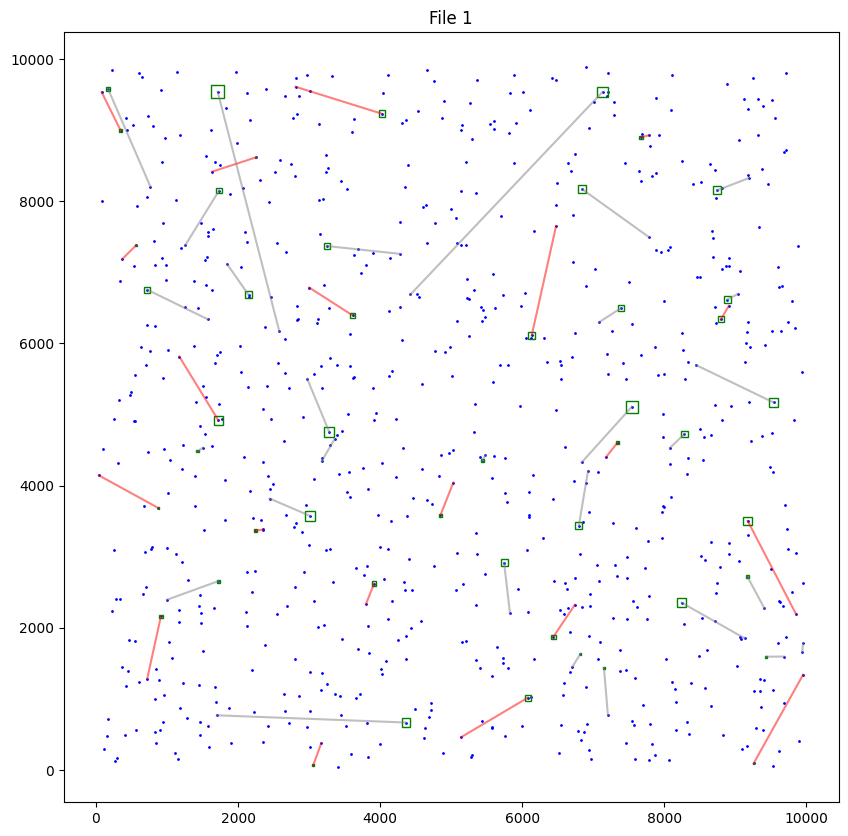

In [ ]:
FILE_NUM = 100

for file_num in range(1, 100):
    input_file_path = f"../in/{file_num:04d}.txt"
    env = Env(input_file_path)
    diffs = []
    for v, (l, r, t, b) in enumerate(env.rectangles):
        diffs.append((v, abs(l - r) + abs(t - b)))

    sorted_diffs = sorted(diffs, key=lambda x: x[1])

    N_POINT = 100
    target_diffs = sorted_diffs[:N_POINT]
    target_inds = [diff[0] for diff in target_diffs]
    target_points = [env.cneter_points[diff[0]] for diff in target_diffs]
    pairs = fast_greedy_pairing(target_points)
    pairs = [(target_inds[i], target_inds[j]) for i, j in pairs]
    pair_centers = []
    for v, q in pairs:
        pair_centers.append(
            [
                (env.cneter_points[v][0] + env.cneter_points[q][0]) / 2,
                (env.cneter_points[v][1] + env.cneter_points[q][1]) / 2,
            ]
        )
    sample_points = farthest_point_sampling(np.array(pair_centers), 20)
    print(sample_points)

    # figsizeをでかく
    fig, ax = plt.subplots(figsize=(10, 10))
    center_points = np.array(env.cneter_points)
    plt.scatter(center_points[:, 0], center_points[:, 1], c="blue", label="Points", s=1)
    # pairを描画
    for i, (v, q) in enumerate(pairs):
        plt.plot(
            [center_points[v][0], center_points[q][0]],
            [center_points[v][1], center_points[q][1]],
            c="red" if i in sample_points else "gray",
            alpha=0.5,
        )
        l, r, t, b = env.rectangles[v]
        ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, edgecolor="green", facecolor="none"))

    plt.title(f"File {file_num}")
    plt.show()
    break
# plt.hist(all_cnts, bins=20, range=(0, 50), alpha=0.7)

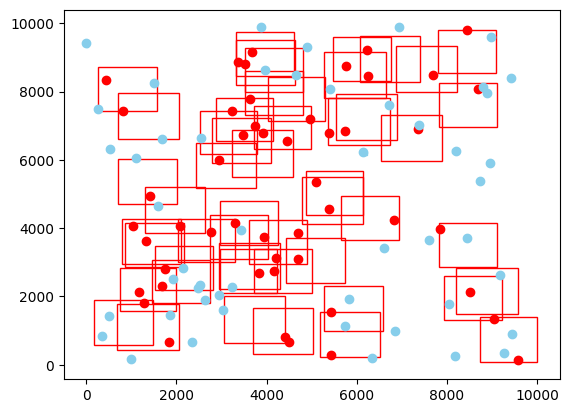

In [20]:
def view(env):
    "点とそれに対応する四角形を表示する"
    area = []
    for i, r in enumerate(env.rectangles):
        area.append((i, (r[1] - r[0]) * (r[3] - r[2])))
    area.sort(key=lambda x: x[1], reverse=False)
    area_ind_all = [i[0] for i in area]
    area_ind = area_ind_all[-50:]

    fig, ax = plt.subplots()
    for i in area_ind:
        now_color = matplotlib.cm.tab20(i)
        now_color = "red"
        x, y = env.coordinates[i]
        a, b, c, d = env.rectangles[i]
        ax.add_patch(plt.Rectangle((a, c), b - a, d - c, fill=False, edgecolor=now_color))
        ax.plot(x, y, "o", color=now_color)

    area_ind = area_ind_all[:50]
    for i in area_ind:
        now_color = matplotlib.cm.tab20(i)
        now_color = "skyblue"
        x, y = env.coordinates[i]
        a, b, c, d = env.rectangles[i]
        ax.add_patch(plt.Rectangle((a, c), b - a, d - c, fill=False, edgecolor=now_color))
        ax.plot(x, y, "o", color=now_color)

    plt.show()


view(env)

In [5]:
import copy

In [6]:
class UnionFind:
    def __init__(self, n):
        self.n = n
        self.parents = [-1] * n

    def find(self, x):
        if self.parents[x] < 0:
            return x
        else:
            self.parents[x] = self.find(self.parents[x])
            return self.parents[x]

    def union(self, x, y):
        x = self.find(x)
        y = self.find(y)

        if x == y:
            return

        if self.parents[x] > self.parents[y]:
            x, y = y, x

        self.parents[x] += self.parents[y]
        self.parents[y] = x

    def size(self, x):
        return -self.parents[self.find(x)]

    def same(self, x, y):
        return self.find(x) == self.find(y)

    def members(self, x):
        root = self.find(x)
        return [i for i in range(self.n) if self.find(i) == root]

    def roots(self):
        return [i for i, x in enumerate(self.parents) if x < 0]

    def group_count(self):
        return len(self.roots())

    def all_group_members(self):
        ret = dict()
        for i in range(self.n):
            r = self.find(i)
            if r in ret:
                ret[r].append(i)
            else:
                ret[r] = [i]
        return ret

    def __str__(self):
        return "\n".join("{}: {}".format(r, self.members(r)) for r in self.roots())


def kruskals_algorithm(edges, N):
    """最小全域木[クラスカル法] O(ElogV)
    edges : (c, a, b) 事前にソートしておくこと
    """
    uf = UnionFind(N)
    cost = 0
    ans_edges = []
    for edge in edges:
        c, a, b = edge
        if not uf.same(a, b):
            cost += c
            uf.union(a, b)
            ans_edges.append((a, b))
    return cost, ans_edges


def prim(graph: dict[int, list[tuple[int, int]]]) -> list[tuple[int, int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(graph.keys())
    used = {v: False for v in v_list}

    init_v = v_list[0]  # 適当な点を選ぶ
    used[init_v] = True
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    while que:
        cost_v, from_v, to_v = heapq.heappop(que)
        if used[to_v]:
            continue
        used[to_v] = True
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        for nxt, cost_nxt in graph[to_v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v


def prim_k(graph: dict[int, list[tuple[int, int]]], init_v: int, k: int, used_v: set[int]) -> list[tuple[int, int]]:
    """
    init_vを含むk頂点の最小全域木を求める
    """
    used = copy.copy(used_v)
    used.add(init_v)
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    ans_cost = 0
    while que:
        if len(ans_v) >= k:
            break
        cost_v, from_v, to_v = heapq.heappop(que)
        if to_v in used:
            continue
        used.add(to_v)
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        ans_cost += cost_v
        for nxt, cost_nxt in graph[to_v]:
            if nxt in used:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v, ans_cost

In [ ]:
from collections import defaultdict

# 中心座標をもとにグラフを作成
graph = defaultdict(list)
for v in range(env.N):
    for q in range(env.N):
        if v == q:
            continue
        dist = (
            abs(env.cneter_points[v][0] - env.cneter_points[q][0]) ** 2
            + abs(env.cneter_points[v][1] - env.cneter_points[q][1]) ** 2
        )
        dist = dist**0.5
        graph[v].append((q, dist))
        graph[q].append((v, dist))

In [8]:
INF = 10**18

groups = [(i, g) for i, g in enumerate(env.G)]
groups = sorted(groups, key=lambda x: x[1], reverse=True)

ans_edges = [None for _ in range(len(groups))]
ans_v = [None for _ in range(len(groups))]

now_used = set()
for group_n, group_size in groups:
    now_cost = INF
    min_cost_ans = None
    for v in range(env.N):
        if v in now_used:
            continue
        prim_edges, prim_v, cost = prim_k(graph, v, group_size, now_used)
        if cost < now_cost:
            now_cost = cost
            min_cost_ans = prim_edges, prim_v
        break
    prim_edges, prim_v = min_cost_ans
    ans_edges[group_n] = prim_edges
    ans_v[group_n] = prim_v
    now_used.update(prim_v)

env.answer(ans_v, ans_edges, "../out/0000.txt")

In [9]:
# 点と全域木を表示
def view_edges(env, edges):
    fig, ax = plt.subplots()
    for i in range(env.N):
        x, y = env.coordinates[i]
        ax.plot(x, y, "o", color="black")
    for e in edges:
        x1, y1 = env.coordinates[e[0]]
        x2, y2 = env.coordinates[e[1]]
        ax.plot([x1, x2], [y1, y2], color="red")
    plt.show()

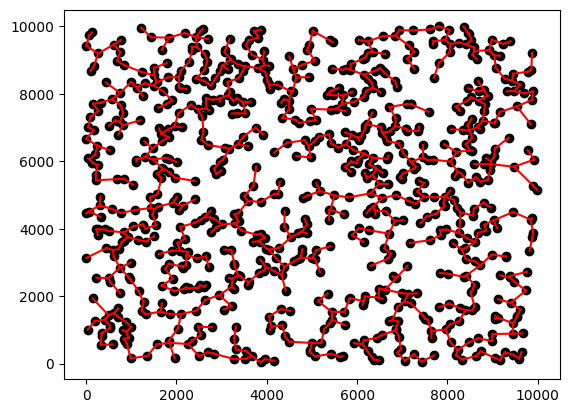

In [ ]:
edges = []
for v in range(env.N):
    for q in range(env.N):
        if v == q:
            continue
        dist = (
            abs(env.coordinates[v][0] - env.coordinates[q][0]) ** 2
            + abs(env.coordinates[v][1] - env.coordinates[q][1]) ** 2
        )
        dist = dist**0.5
        edges.append((dist, v, q))

edges = sorted(edges, key=lambda x: x[0])
ans_cost, ans_edges = kruskals_algorithm(edges, env.N)
view_edges(env, ans_edges)

In [11]:
# area = []
# for r in env.rectangles:
#     area.append((r[1] - r[0]) * (r[3] - r[2]))

# sorted(area)

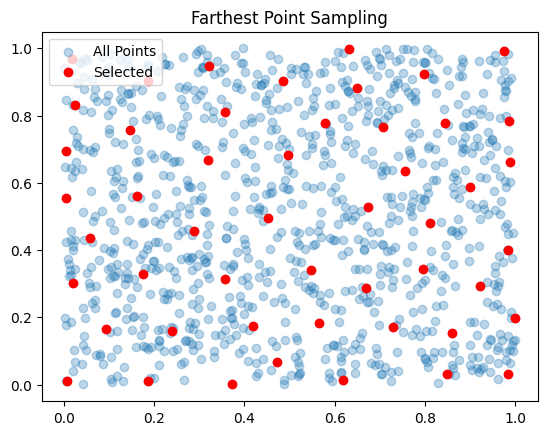

In [53]:
import numpy as np


def farthest_point_sampling(points: np.ndarray, M: int) -> np.ndarray:
    N = len(points)
    selected_indices = []

    # ランダムに1点選ぶ
    idx = np.random.randint(0, N)
    selected_indices.append(idx)

    # 距離を格納する配列（各点から選ばれた点群までの最小距離）
    min_distances = np.full(N, np.inf)

    for _ in range(1, M):
        # 最後に追加した点
        last_point = points[selected_indices[-1]]

        # 全点からその点までの距離を計算
        distances = np.linalg.norm(points - last_point, axis=1)

        # 最小距離を更新（すでに選ばれた点群からの最小距離）
        min_distances = np.minimum(min_distances, distances)

        # 最小距離が最大となる点を選ぶ（＝一番離れている）
        next_idx = np.argmax(min_distances)
        selected_indices.append(next_idx)

    return points[selected_indices]


import matplotlib.pyplot as plt

np.random.seed(0)
N = 1000
M = 50
points = np.random.rand(N, 2)

selected = farthest_point_sampling(points, M)

plt.scatter(points[:, 0], points[:, 1], alpha=0.3, label="All Points")
plt.scatter(selected[:, 0], selected[:, 1], color="red", label="Selected")
plt.legend()
plt.title("Farthest Point Sampling")
plt.show()


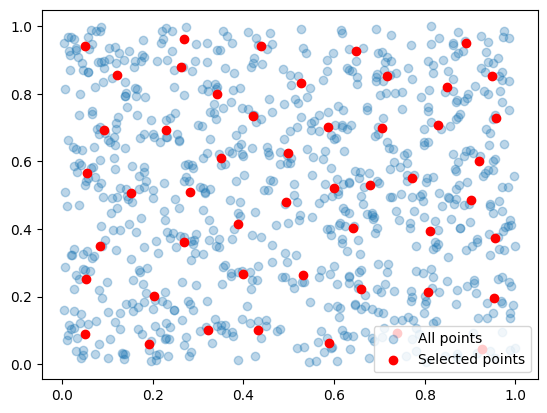

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans


def select_diverse_points(points, M):
    # 初期点をランダムに1つ選ぶ
    selected = [points[np.random.choice(len(points))]]

    for _ in range(M - 1):
        # 残りの点の中で、選ばれた点群から最も遠い点を選ぶ
        distances = np.array([min(np.linalg.norm(p - s) for s in selected) for p in points])
        next_point = points[np.argmax(distances)]
        selected.append(next_point)

    return np.array(selected)


def kmeans_representative(points, M):
    kmeans = KMeans(n_clusters=M, random_state=0).fit(points)
    centers = kmeans.cluster_centers_
    return centers


# 2次元のランダムな点を生成
np.random.seed(42)
points = np.random.rand(800, 2)

# M点だけ選定
selected = kmeans_representative(points, M=50)

# 可視化
plt.scatter(points[:, 0], points[:, 1], label="All points", alpha=0.3)
plt.scatter(selected[:, 0], selected[:, 1], color="red", label="Selected points")
plt.legend()
plt.show()


- ゆらぎの少ない 2 点で、かつ、2 点の間が小さいものを基準にする
- その 2 点の垂直二等分線でポリゴンが切れて、2 点がなすひし形とかぶらないポリゴンを見つけてくる
- そのポリゴンの中で最も面積の大きいポリゴンを選択
  - できれば平等に分割できるポリゴンがうれしい
    - 適当に 10%以上で分割できることとする？
- 3 点クエリを行い、本当の点がどこに存在するかを求める
- 上記を 400 回繰り返す

800 _ 400
3.2 _ 10^5


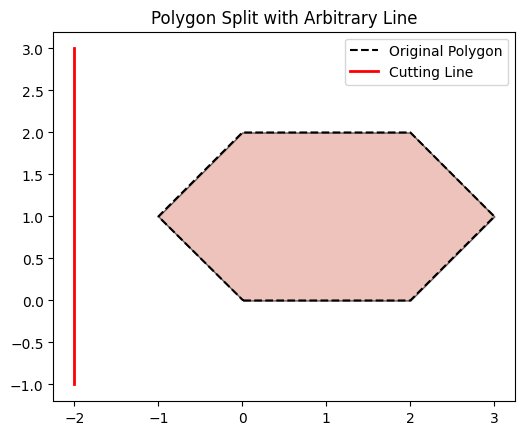

=== Polygon Areas ===
Polygon 1 Area: 5.995

Point (-0.5, 0.6) is inside original polygon? True


In [ ]:
from shapely.geometry import Polygon, LineString, Point
from shapely.ops import split
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import random


def split_polygon_with_line(polygon_points, cut_point1, cut_point2):
    polygon = Polygon(polygon_points)
    cutting_line = LineString([cut_point1, cut_point2])
    result = split(polygon, cutting_line)
    polygons = [geom for geom in result.geoms if isinstance(geom, Polygon)]
    return polygons, cutting_line


def plot_polygons(original_points, polygons, cutting_line):
    fig, ax = plt.subplots()
    ax.plot(*zip(*original_points, original_points[0]), "k--", label="Original Polygon")

    patches = []
    colors = []
    for poly in polygons:
        mpl_poly = MplPolygon(list(poly.exterior.coords), closed=True)
        patches.append(mpl_poly)
        colors.append((random.random(), random.random(), random.random()))

    p = PatchCollection(patches, facecolor=colors, edgecolor="k", alpha=0.6)
    ax.add_collection(p)

    x, y = cutting_line.xy
    ax.plot(x, y, "r-", linewidth=2, label="Cutting Line")

    ax.set_aspect("equal")
    ax.legend()
    plt.title("Polygon Split with Arbitrary Line")
    plt.show()


def is_point_inside_polygon(polygon_points, point):
    polygon = Polygon(polygon_points)
    return polygon.contains(Point(point))


def calculate_polygon_area(polygon_points):
    polygon = Polygon(polygon_points)
    return polygon.area


# 六角形のポリゴン
polygon_points = [(0.01, 0), (2, 0), (3, 1), (2, 2), (0, 2), (-1, 1)]

# 任意の2点で分割
cut_point1 = (-2, -1)
cut_point2 = (-2, 3)

# 分割
result_polygons, cutting_line = split_polygon_with_line(polygon_points, cut_point1, cut_point2)

# 描画
plot_polygons(polygon_points, result_polygons, cutting_line)

# 面積表示
print("=== Polygon Areas ===")
for v, poly in enumerate(result_polygons):
    print(f"Polygon {v + 1} Area: {poly.area}")

# 点の内包チェック
test_point = (-0.5, 0.6)
inside = is_point_inside_polygon(polygon_points, test_point)
print(f"\nPoint {test_point} is inside original polygon? {inside}")


POLYGON ((2 2, 3 1, 1 1, 0 2, 2 2))
array('d', [2.0, 3.0, 1.0, 0.0, 2.0]) array('d', [2.0, 1.0, 1.0, 2.0, 2.0])


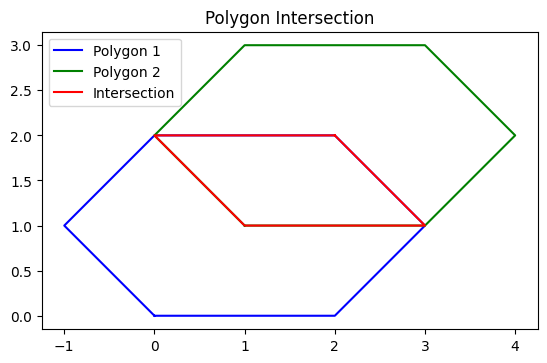

In [ ]:
from shapely.geometry import Polygon

# 2つのポリゴンを定義（10角形）、重ならないようにする
polygon1 = Polygon([(0, 0), (2, 0), (3, 1), (2, 2), (0, 2), (-1, 1)])
polygon2 = Polygon([(1, 1), (3, 1), (4, 2), (3, 3), (1, 3), (0, 2)])
# polygon2 = Polygon([(4, 4), (6, 4), (7, 5), (6, 6), (4, 6), (3, 5)])

# 共通部分（交差部分）を取得
intersection = polygon1.intersection(polygon2)
print(intersection)


# polygon1、 polygon2、intersectionを描画
def plot_polygons_with_intersection(polygon1, polygon2, intersection):
    fig, ax = plt.subplots()
    x1, y1 = polygon1.exterior.xy
    x2, y2 = polygon2.exterior.xy
    x_int, y_int = intersection.exterior.xy
    print(x_int, y_int)

    ax.plot(x1, y1, color="blue", label="Polygon 1")
    ax.plot(x2, y2, color="green", label="Polygon 2")
    ax.plot(x_int, y_int, color="red", label="Intersection")

    ax.set_aspect("equal")
    ax.legend()
    plt.title("Polygon Intersection")
    plt.show()


plot_polygons_with_intersection(polygon1, polygon2, intersection)

11.0


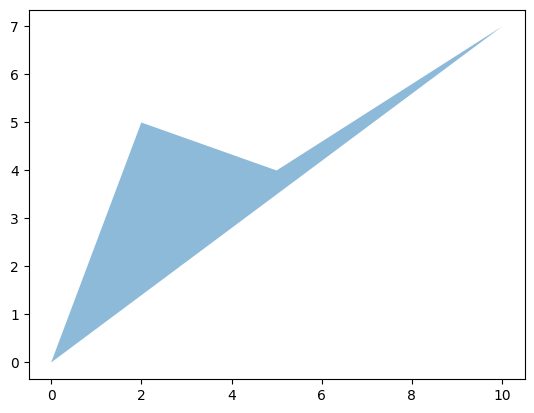

In [ ]:
import matplotlib
import matplotlib.pyplot as plt


class Polygon:
    def __init__(self, vertices: list[tuple[float, float]]):
        self.vertices = vertices

    def area(self) -> float:
        n = len(self.vertices)
        area = 0.0
        for i in range(n):
            x1, y1 = self.vertices[i]
            x2, y2 = self.vertices[(i + 1) % n]
            area += x1 * y2 - x2 * y1
        return abs(area) / 2.0

    def division(self, v1: tuple[float, float], v2: tuple[float, float]) -> list[tuple[float, float]]:
        # v1とv2を結ぶ直線で多角形を2つに分割する
        
    def draw(self):
        x, y = zip(*self.vertices)
        plt.fill(x, y, alpha=0.5)
        plt.show()


# polygon = Polygon([(10, 7), (0, 0), (5, 4), (2, 5)])
polygon = Polygon([(10, 7), (0, 0), (2, 5), (5, 4)])
print(polygon.area())  # 7.5

polygon.draw()